<a href="https://colab.research.google.com/github/Ashwiniii04/-Pairwise-Sequence-Alignment-Tool/blob/main/Timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install --quiet pmdarima statsmodels matplotlib pandas numpy scikit-learn

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm

KeyboardInterrupt: 

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm

In [7]:
#Create a monthly date index for periods points.
#Build a linear trend component and a yearly seasonal component.
#Add Gaussian noise to make the series realistic.
periods = 120
time_index = pd.date_range("2015-01-01", periods=periods, freq="ME")
trend = np.linspace(50, 120, periods)
season = 10 * np.sin(2 * np.pi * time_index.month / 12)
noise = np.random.normal(0, 5, periods)

ts = trend + season + noise

In [8]:
#Create DataFrame
#Put the generated series into a pandas DataFrame with a Date index.
#Setting the Date as index is important for plotting, resampling and time aware operations
data = pd.DataFrame({"Date": time_index, "Value": ts})
data.set_index("Date", inplace=True)
data.head()

,Value
Date,
2015-01-31,59.037280
2015-02-28,56.863013
2015-03-31,66.205196
2015-04-30,62.434003
2015-05-31,50.473093


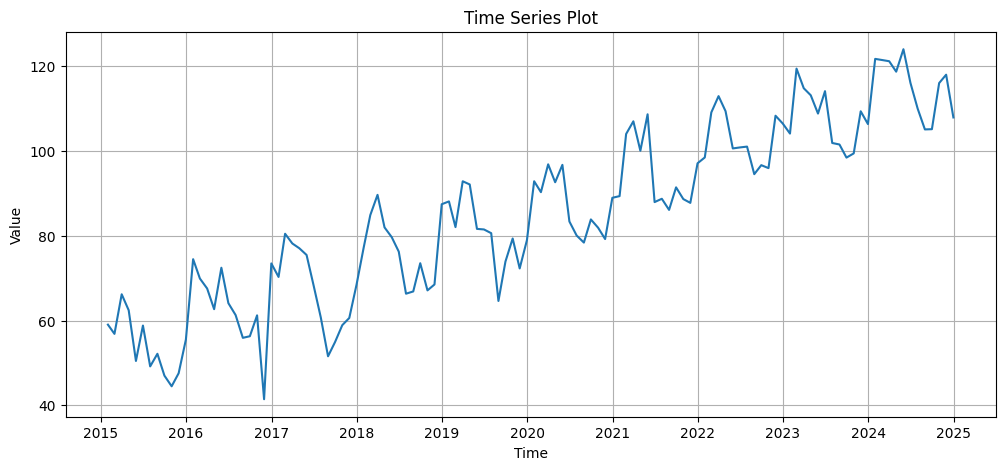

In [9]:
#Visualize the raw time series
#Plot the observed series to inspect trend and seasonality.
#A quick visual check helps decide preprocessing and modelling choices.
plt.figure(figsize=(12,5))
plt.plot(data.Value)
plt.title("Time Series Plot")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.show()